# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

https://1drv.ms/v/c/808ebfd9a0d86213/IQCLY6g2vuPjQr-7RxF_QZK0AWue-PxKWmQ8QlMEtwIh2WA?e=qBwOpD

In [3]:
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_genes = pd.read_csv("dataframe_genes.csv", index_col="Unnamed: 0")
df_genes = df_genes.T
df_genes 

,Nome do gene,Tamanho do gene,Início do nome do gene,Número de A's no nome do gene,HU no nome do gene
BRCA1,BRCA1,5,BR,1,False
CDKN2A,CDKN2A,6,CD,1,False
TP53,TP53,4,TP,0,False
KRAS,KRAS,4,KR,1,False
SMAD4,SMAD4,5,SM,1,False


In [5]:
df_genes['id_entrez'] = [
    "NM_007294.4",
    "NM_000077.5",
    "NM_000546.6",
    "NM_004985.5",
    "NM_005359.6",
]

df_genes['id_protein'] = [
    'NP_009225.1',
    "NP_000068.1",
    "NP_000537.3",
    "NP_004976.2",
    "NP_005350.1",
]
df_genes

,Nome do gene,Tamanho do gene,Início do nome do gene,Número de A's no nome do gene,HU no nome do gene,id_entrez,id_protein
BRCA1,BRCA1,5,BR,1,False,NM_007294.4,NP_009225.1
CDKN2A,CDKN2A,6,CD,1,False,NM_000077.5,NP_000068.1
TP53,TP53,4,TP,0,False,NM_000546.6,NP_000537.3
KRAS,KRAS,4,KR,1,False,NM_004985.5,NP_004976.2
SMAD4,SMAD4,5,SM,1,False,NM_005359.6,NP_005350.1


In [8]:
def salvar_fasta_gene(id_protein: str, nome_gene: str) -> None:
    '''
        Salva a sequência de um gene em formato FASTA.
            Args:
                id_protein (str): ID do gene no GenBank.
                nome_gene (str): Nome do gene para salvar o arquivo.
            Returns:
                None
    '''
    # Necessário informar seu email
    Entrez.email = "gaby.koerich@hotmail.com"

    # Busca a sequência (ex: um ID do GenBank)
    handle = Entrez.efetch(db="protein", id=id_protein, rettype="fasta", retmode="text")
    record = handle.read()
    handle.close()

    # Salva o arquivo
    with open(f"{nome_gene}.fasta", "w") as f:
        fasta = f.write(record)
    
    return None

In [19]:
def obter_sequencia(id_protein: str) -> str:
    Entrez.email = "seu_email@email.com"
    
    handle = Entrez.efetch(
        db="protein",
        id=id_protein,
        rettype="fasta",
        retmode="text"
    )
    
    record = handle.read()
    handle.close()

    linhas = record.split("\n")
    sequencia = "".join(linhas[1:])
    
    return sequencia

In [ ]:
sequencias = []

for index in df_genes.index:
    id_gene = df_genes.loc[index, "id_protein"]
    
    seq = obter_sequencia(id_gene)
    sequencias.append(seq)
    
    time.sleep(1) 

df_genes["sequencia"] = sequencias

In [ ]:
for index in df_genes.index:
    id_gene = df_genes.loc[index, "id_protein"]
    nome_gene = index 
    salvar_fasta_gene(nome_gene=nome_gene, id_protein=id_gene)
    time.sleep(10)  # Para evitar sobrecarga no servidor do NCBI
    print(nome_gene, id_gene)
   

BRCA1 NP_009225.1
CDKN2A NP_000068.1
TP53 NP_000537.3
KRAS NP_004976.2
SMAD4 NP_005350.1


In [21]:
df_genes

,Nome do gene,Tamanho do gene,Início do nome do gene,Número de A's no nome do gene,HU no nome do gene,id_entrez,id_protein,sequencia
BRCA1,BRCA1,5,BR,1,False,NM_007294.4,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...
CDKN2A,CDKN2A,6,CD,1,False,NM_000077.5,NP_000068.1,MEPAAGSSMEPSADWLATAAARGRVEEVRALLEAGALPNAPNSYGR...
TP53,TP53,4,TP,0,False,NM_000546.6,NP_000537.3,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...
KRAS,KRAS,4,KR,1,False,NM_004985.5,NP_004976.2,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...
SMAD4,SMAD4,5,SM,1,False,NM_005359.6,NP_005350.1,MDNMSITNTPTSNDACLSIVHSLMCHRQGGESETFAKRAIESLVKK...


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [23]:
aminoacidos = list("ACDEFGHIKLMNPQRSTVWY")

frequencias = {}

for gene in df_genes.index:
    seq = df_genes.loc[gene, "sequencia"]
    seq = seq.replace("\n", "").strip()
    
    contagem = {}
    for aa in aminoacidos:
        contagem[aa] = seq.count(aa)
    
    frequencias[gene] = contagem

df_freq = pd.DataFrame.from_dict(frequencias, orient="index")

df_freq

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
BRCA1,84,44,85,198,49,87,49,77,137,156,30,121,96,97,76,224,111,101,10,31
CDKN2A,29,1,11,11,1,14,5,3,0,17,5,4,11,1,17,7,5,10,2,2
TP53,24,10,20,30,11,23,12,8,20,32,12,14,45,15,26,38,22,18,4,9
KRAS,9,4,16,13,6,12,4,12,21,11,6,4,4,9,10,10,13,16,0,8
SMAD4,48,14,26,25,13,40,30,29,20,41,10,19,45,32,24,45,32,33,8,18


## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [24]:
gene_max = df_freq["V"].idxmax()
valor_max = df_freq["V"].max()

print(f"O gene com mais valinas é {gene_max} com {valor_max} resíduos de V.")

O gene com mais valinas é BRCA1 com 101 resíduos de V.


## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [27]:
media = df_freq["S"].mean()
mediana = df_freq["S"].median()
moda = df_freq["S"].mode()

print("Média da frequência absoluta de Serina:", media)
print("Mediana da frequência abssoluta de Serina:", mediana)
print("Moda da frequência absoluta de Serina:", moda.values)

Média da frequência absoluta de Serina: 64.8
Mediana da frequência abssoluta de Serina: 38.0
Moda da frequência absoluta de Serina: [  7  10  38  45 224]


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

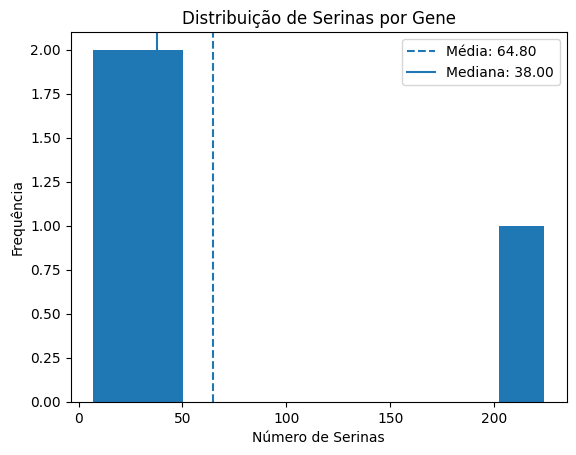

In [30]:
serinas = df_freq["S"]

media = serinas.mean()
mediana = serinas.median()

plt.figure()
plt.hist(serinas, bins=10)

plt.axvline(media, linestyle='--', label=f"Média: {media:.2f}")
plt.axvline(mediana, linestyle='-', label=f"Mediana: {mediana:.2f}")

plt.title("Distribuição de Serinas por Gene")
plt.xlabel("Número de Serinas")
plt.ylabel("Frequência")
plt.legend()

plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

In [34]:
def histograma_aminoacido(df_freq, aa):
    if aa not in df_freq.columns:
        print("Aminoácido inválido!")
        return
    
    dados = df_freq[aa]
    
    media = dados.mean()
    mediana = dados.median()
    
    bins = range(int(dados.min()), int(dados.max()) + 2)
    
    plt.figure()
    plt.hist(dados, bins=bins)
    
    plt.axvline(media, linestyle='--', label=f"Média: {media:.2f}")
    plt.axvline(mediana, linestyle='-', label=f"Mediana: {mediana:.2f}")
    
    plt.title(f"Histograma do número de {aa} por gene")
    plt.xlabel(f"Quantidade de {aa}")
    plt.ylabel("Número de genes")
    plt.legend()
    
    plt.show()

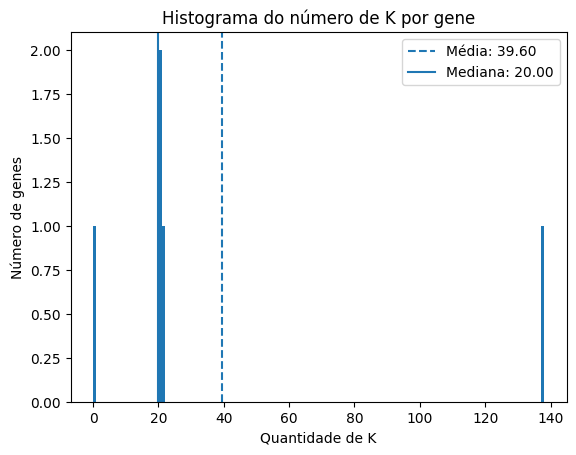

In [35]:
histograma_aminoacido(df_freq, "K")

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

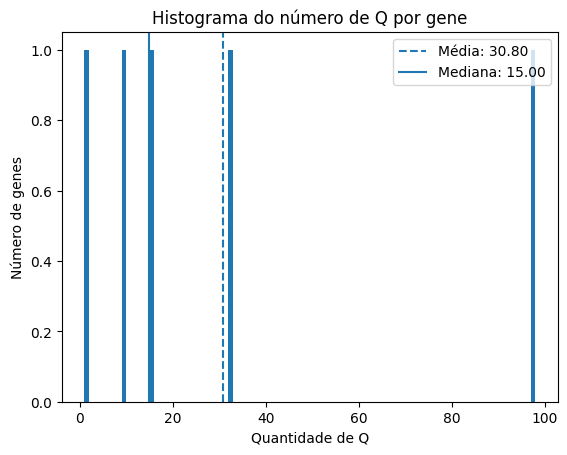

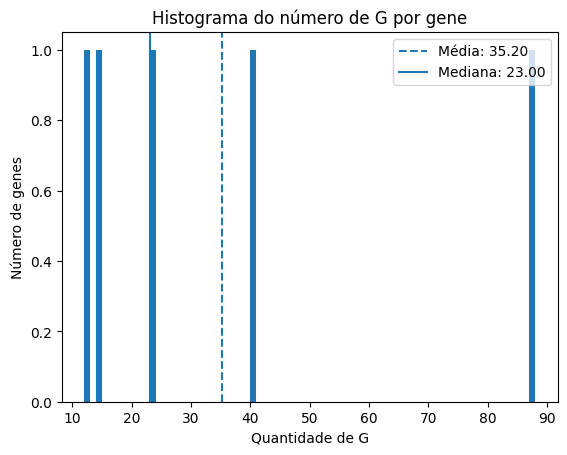

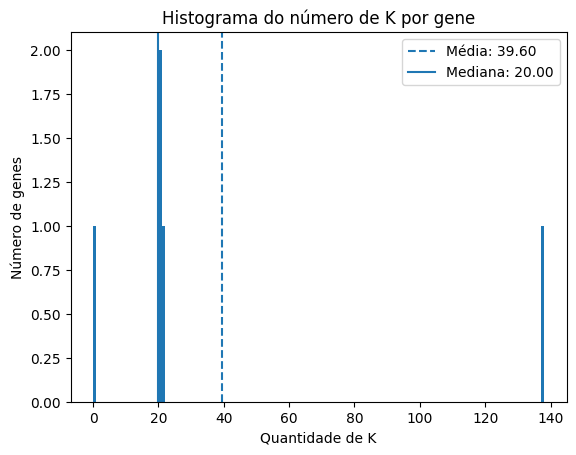

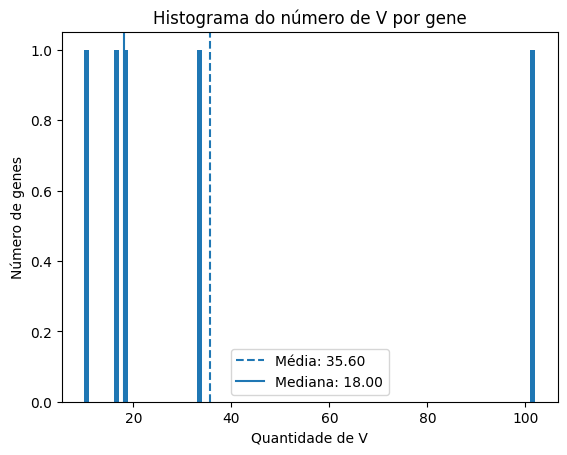

In [36]:
histograma_aminoacido(df_freq, "Q")
histograma_aminoacido(df_freq, "G")
histograma_aminoacido(df_freq, "K")
histograma_aminoacido(df_freq, "V")

In [38]:
diferencas = (df_freq[["Q","G","K","V"]].mean() - 
              df_freq[["Q","G","K","V"]].median()).abs()

aa_menor = diferencas.idxmin()
valor_menor = diferencas.min()

nomes = {
    "Q": "Glutamina",
    "G": "Glicina",
    "K": "Lisina",
    "V": "Valina"
}

print(f"O aminoácido com menor diferença entre média e mediana é {nomes[aa_menor]} ({aa_menor}), com diferença de {valor_menor:.2f}.")

O aminoácido com menor diferença entre média e mediana é Glicina (G), com diferença de 12.20.


## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [39]:
primeiros = df_freq.head(3)

cisteina = primeiros["C"]

media = cisteina.mean()
mediana = cisteina.median()

print(f"Média de Cisteína dentre os três primeiros genes: {media}")
print(f"Mediana de Cisteína dentre os três primeiros genes: {mediana}")

Média de Cisteína dentre os três primeiros genes: 18.333333333333332
Mediana de Cisteína dentre os três primeiros genes: 10.0


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [40]:
media_por_gene = df_freq.mean(axis=1)

gene_maior = media_por_gene.idxmax()
valor_maior = media_por_gene.max()

print(f"O gene com maior número médio de aminoácidos é {gene_maior}, com média de {valor_maior:.2f}.")

O gene com maior número médio de aminoácidos é BRCA1, com média de 93.15.


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [41]:
media_por_gene = df_freq.mean(axis=1)

gene_menor = media_por_gene.idxmin()
valor_menor = media_por_gene.min()

print(f"O gene com menor número médio de aminoácidos é {gene_menor}, com média de {valor_menor:.2f}.")

O gene com menor número médio de aminoácidos é CDKN2A, com média de 7.80.
